In [1]:
# Proyecto de GAUSS MIXTURE MODEL
# Importación de bibliotecas necesarias

from sklearn.mixture import GaussianMixture

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.metrics import silhouette_score


In [2]:
# Cargar el dataset (el archivo CSV)
df = pd.read_csv('../../data/dataset_for_clustering.csv')

In [3]:
mask = df['Country'] == "United Kingdom"
df = df[mask]
# Revisamos los primeros registros
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,Day,DayOfWeek,Quarter,Season
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,2,4,Winter
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,2,4,Winter
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,2,4,Winter
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,2010,12,1,2,4,Winter
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010,12,1,2,4,Winter
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010,12,1,2,4,Winter
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010,12,1,2,4,Winter
9,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.10,13047.0,United Kingdom,12.60,2010,12,1,2,4,Winter


In [4]:
# Configuración de datos

df_grouped = df.groupby(['InvoiceNo', 'CustomerID'])['TotalSales'].sum().reset_index()
df_grouped

df_to_use = df_grouped.groupby(['CustomerID']).agg({
  "TotalSales": "sum",
  "InvoiceNo": "count"
}).reset_index()

df_to_use


,CustomerID,TotalSales,InvoiceNo
0,12747.0,1959.01,11
1,12748.0,24601.48,214
2,12749.0,3615.00,8
3,12820.0,942.34,4
4,12821.0,92.72,1
...,...,...,...
3826,18280.0,180.60,1
3827,18281.0,80.82,1
3828,18282.0,176.60,3
3829,18283.0,2045.53,16


In [5]:
# Calcular la media del ticket (promedio de 'TotalSales' por factura)
df_to_use['mediaTicket'] = df_to_use['TotalSales'] / df_to_use['InvoiceNo']

# Ordenar por número de facturas
df_to_use = df_to_use.sort_values('InvoiceNo')
df_to_use


,CustomerID,TotalSales,InvoiceNo,mediaTicket
15,12834.0,312.38,1,312.380000
14,12833.0,417.38,1,417.380000
12,12831.0,215.05,1,215.050000
6,12824.0,397.12,1,397.120000
4,12821.0,92.72,1,92.720000
...,...,...,...,...
183,13089.0,32484.99,100,324.849900
1731,15311.0,13532.11,113,119.753186
1239,14606.0,10969.59,127,86.374724
3518,17841.0,35683.76,169,211.146509


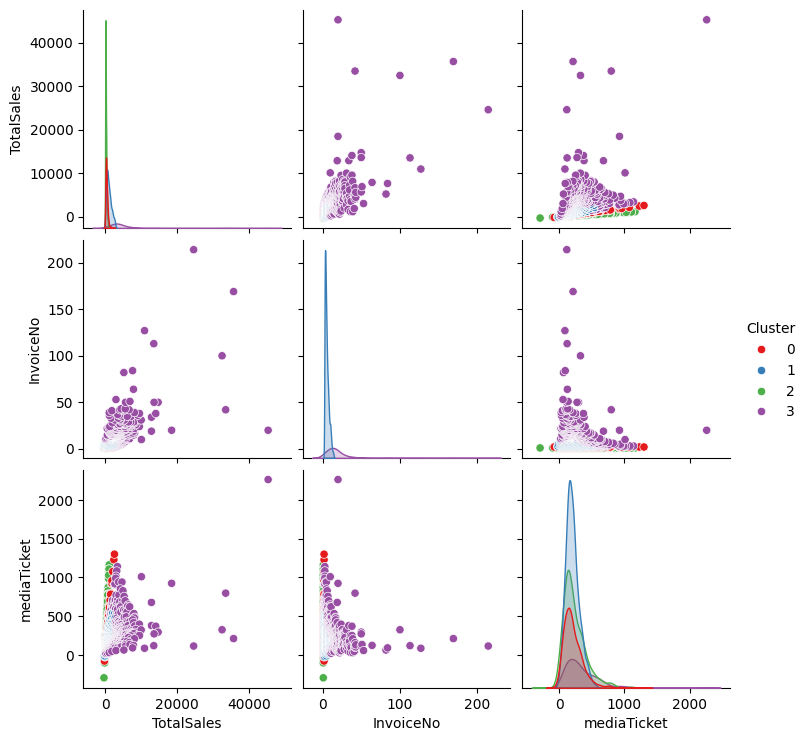

In [6]:
camposUsar = df_to_use[['TotalSales', 'InvoiceNo', 'mediaTicket']]


# Escalar los datos (opcional pero recomendable para GMM)
scaler = StandardScaler()
camposUsar_scaled = scaler.fit_transform(camposUsar)


# Aplicar Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=4, random_state=42)
df_to_use["Cluster"] = gmm.fit_predict(camposUsar_scaled)  # Añadimos al df la predicción, nº cluster de cada punto

# Visualización de los clusters obtenidos
sns.pairplot(df_to_use, hue="Cluster", vars=['TotalSales', 'InvoiceNo', 'mediaTicket'], palette='Set1')
plt.show()


In [7]:
# Ver las primeras filas del DataFrame con los clusters asignados
print(df_to_use.head())

# Si deseas calcular la puntuación de Silhouette para evaluar la calidad de los clusters
silhouette_avg = silhouette_score(camposUsar_scaled, df_to_use["Cluster"])
print(f"Puntuación de Silhouette: {silhouette_avg}")

    CustomerID  TotalSales  InvoiceNo  mediaTicket  Cluster
15     12834.0      312.38          1       312.38        2
14     12833.0      417.38          1       417.38        2
12     12831.0      215.05          1       215.05        2
6      12824.0      397.12          1       397.12        2
4      12821.0       92.72          1        92.72        2
Puntuación de Silhouette: 0.0501812341680597
